In [ ]:
ROOT = "<CODE_ROOT_PATH>"
DATA_ROOT = "<DATA_ROOT_PATH>"

In [2]:
import pandas as pd
from PIL import Image
import numpy as np
from tqdm.notebook import tqdm
import torch
import random
import os
os.chdir(ROOT)

In [3]:
from tokeniser import get_tokenizer
tokenizer = get_tokenizer()

[153, 116, 154, 231, 153, 105, 154, 232, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [4]:
from dataloader import UrduNewsDataset

dataset = UrduNewsDataset(root=DATA_ROOT, dataset_path = "urdu-news-dataset-1M.csv", tokenizer=tokenizer, max_length=512)

Detected encoding: UTF-8-SIG


In [5]:
print("Number of training examples:", len(dataset))

Number of training examples: 1038340


In [6]:
N = 3

encoding = dataset[N]["input_ids"]
print("Input IDs:", encoding)
print(encoding.shape)

Input IDs: tensor([  0, 153, 105, 153, 116, 154, 231, 153, 105, 154, 232, 225, 153, 105,
        153, 106, 153, 105, 153, 112, 225, 154, 127, 153, 105, 155, 107, 153,
        116, 153, 108, 153, 105, 154, 233, 225, 154, 232, 156, 239, 155, 123,
        225, 154, 232, 153, 105, 156, 228, 225, 154, 233, 154, 235, 154, 232,
        153, 106, 153, 114, 225, 154, 232, 156, 239, 155, 123, 225, 154, 232,
        153, 116, 154, 231, 153, 116, 154, 231, 225, 153, 108, 156, 239, 153,
        116, 153, 114, 156, 245, 225, 154, 232, 156, 228, 156, 239, 154, 233,
        156, 245, 225, 153, 106, 153, 114, 153, 105, 154, 232, 153, 112, 153,
        105, 153, 108, 225, 154, 232, 156, 239, 155, 123, 225, 153, 105, 153,
        119, 153, 105, 154, 228, 156, 228, 225, 153, 112, 156, 239, 155, 107,
        155, 127, 153, 105, 225, 155, 112, 156, 239, 153, 105, 225, 153, 105,
        154, 235, 153, 114, 225, 156, 239, 156, 228, 225, 155, 112, 153, 115,
        153, 117, 153, 108, 156, 228, 225, 154, 232, 

In [7]:
# from transformers import VisionEncoderDecoderModel, RobertaConfig, RobertaForCausalLM, ViTModel
# import torch
from transformers import EncoderDecoderModel
from models import decoder_only_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

decoder = decoder_only_model(vocab_size=tokenizer.vocab_size)
decoder.to(device)

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(261, 256)
    (wpe): Embedding(512, 256)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-2): 3 x GPT2Block(
        (ln_1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=768, nx=256)
          (c_proj): Conv1D(nf=256, nx=256)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=1024, nx=256)
          (c_proj): Conv1D(nf=256, nx=1024)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=256, out_features=261, bias=False)
)

In [8]:
device
torch.cuda.is_available() == True

True

In [9]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./decoder_pretrain_tokenizer_bos_eos",
    per_device_train_batch_size=128,
    gradient_accumulation_steps=1,
    num_train_epochs=4,
    learning_rate=5e-4,
    weight_decay=0.01,
    warmup_steps=1500,
    logging_steps=500,
    save_steps=5000,
    save_total_limit=3,
    bf16=True,
    fp16=False,
    eval_strategy="no",
    eval_steps=1000
)

trainer = Trainer(
    model=decoder,
    args=training_args,
    train_dataset=dataset,
)
trainer.train()

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
500,3.385000
1000,1.643200
1500,1.473400
2000,1.285600
2500,1.145300
3000,1.024700
3500,0.945500
4000,0.894000
4500,0.858600
5000,0.832900


TrainOutput(global_step=32452, training_loss=0.7756424975221818, metrics={'train_runtime': 26685.1359, 'train_samples_per_second': 155.643, 'train_steps_per_second': 1.216, 'total_flos': 3.023646505304064e+16, 'train_loss': 0.7756424975221818, 'epoch': 4.0})

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


Step,Training Loss


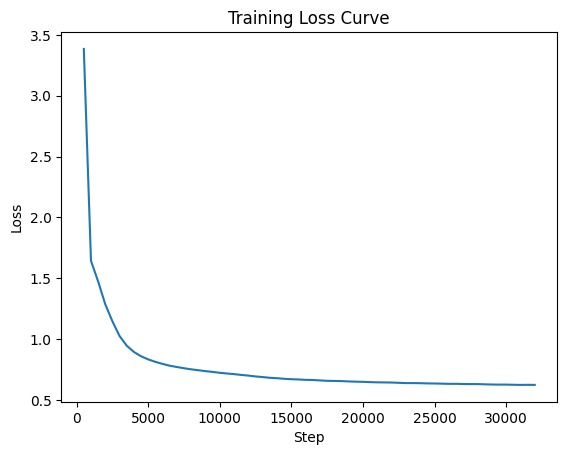

In [11]:
# Load trainer state from checkpoint
trainer.train(resume_from_checkpoint="./decoder_pretrain_tokenizer_bos_eos/checkpoint-32452")

# Plot the training loss curve
import matplotlib.pyplot as plt
loss_values = trainer.state.log_history
steps = [entry['step'] for entry in loss_values if 'loss' in entry]
losses = [entry['loss'] for entry in loss_values if 'loss' in entry]

plt.plot(steps, losses)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.show()